# Urban Heat Intelligence · Leuven 2023–2025

> **AI-assisted urban heat risk prediction using satellite imagery and environmental sensing.**

End-to-end AI pipeline combining **Sentinel-2 satellite imagery** (B04, B08, B11) with  
**Leuven.cool citizen science sensor data** to predict and map urban heat across Leuven.  
Multi-year summer data · 2023 – 2025 · Random Forest · XGBoost · CNN

---

## Table of Contents
1. [Setup & Config](#1-setup--config)
2. [Phase 1 — Data Collection & Loading](#2-phase-1--data-collection--loading)
3. [Phase 2 — Preprocessing & EDA](#3-phase-2--preprocessing--eda)
4. [Phase 3 — Feature Engineering](#4-phase-3--feature-engineering)
5. [Phase 4 — ML Modeling](#5-phase-4--ml-modeling)
6. [Phase 5 — Evaluation & Model Comparison](#6-phase-5--evaluation--model-comparison)
7. [Phase 6 — Visualization & Heat Risk Map](#7-phase-6--visualization--heat-risk-map)
8. [Phase 7 — Deployment](#8-phase-7--deployment)

---
## 1. Setup & Config

> ⚡ **Speed tip:** `MAX_ROWS_PER_YEAR` controls how many rows are sampled per year.  
> Keep `50_000` during development. Set `None` for a full run (slow on large files).

In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import rasterio
from rasterio.transform import rowcol
from pathlib import Path
warnings.filterwarnings('ignore')

# ML
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import (KFold, cross_val_score,
                                     RandomizedSearchCV, StratifiedShuffleSplit)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb

# Deep Learning — CNN
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Visualization
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import seaborn as sns

print('All imports OK')

All imports OK


In [2]:
# ── Paths ──────────────────────────────────────────────────────────────────────
PROJECT_ROOT   = Path('..')
DATA_ROOT      = PROJECT_ROOT / 'data' / 'raw'
LEUVEN_DIR     = DATA_ROOT / 'leuven'
SENTINEL_DIR   = DATA_ROOT / 'sentinel2'
STATIONS_CSV   = LEUVEN_DIR / 'STATIONS.csv'

# ── Speed controls ─────────────────────────────────────────────────────────────
MAX_ROWS_PER_YEAR = 50_000   # set None for full run
PATCH_SIZE        = 16
N_FOLDS           = 5
RANDOM_STATE      = 42
YEARS             = [2023, 2024, 2025]
DEVICE            = 'cuda' if torch.cuda.is_available() else 'cpu'

# Leuven bounding box
LAT_MIN, LAT_MAX = 50.84, 50.94
LON_MIN, LON_MAX = 4.63,  4.78

print(f'Device      : {DEVICE}')
print(f'Sample cap  : {MAX_ROWS_PER_YEAR:,} rows/year')

Device      : cpu
Sample cap  : 50,000 rows/year


---
## 2. Phase 1 — Data Collection & Loading

### 2a. Data Sources

#### Leuven.cool Sensor Network
Crowdsourced citizen science data from ~110 low-cost weather stations (Fine Offset WH2600) across Leuven.  
Source: [Zenodo DOI 10.5281/zenodo.14893734](https://zenodo.org/records/14893734)

Files used: `RAWDATA2023Q3.csv`, `RAWDATA2024Q3.csv`, `RAWDATA2025Q3.csv` (summer Q3, July–September)

| Column | Description | Unit |
|---|---|---|
| TEMPF | Air temperature | °F |
| HUMIDITY | Relative humidity | % |
| SOLARRADIATION | Solar radiation | W/m² |
| WINDSPEEDMPH | Wind speed | mph |
| DEWPTF | Dew point temperature | °F |
| DATEUTC | Server reception timestamp | UTC |

#### Sentinel-2 L2A Imagery
Because Sentinel-2 acquisitions are not available daily, we selected all available **low-cloud summer scenes** for Leuven from Copernicus and matched each with Leuven.cool measurements from the closest available date.

| Scene date | Year | Days from nearest Q3 data |
|---|---|---|
| 2023-08-10 | 2023 | 0 |
| 2023-08-20 | 2023 | 0 |
| 2023-08-23 | 2023 | 0 |
| 2024-07-30 | 2024 | 0 |
| 2025-07-02 | 2025 | 0 |
| 2025-08-11 | 2025 | 0 |
| 2025-08-12 | 2025 | 0 |

Bands used: **B04** (Red), **B08** (NIR), **B11** (SWIR) — B12 excluded.

In [3]:
# ── Sentinel-2 scene inventory ────────────────────────────────────────────────
SCENE_DATES = pd.to_datetime([
    '2023-08-10',
    '2023-08-20',
    '2023-08-23',
    '2024-07-30',
    '2025-07-02',
    '2025-08-11',
    '2025-08-12',
])

scene_inventory = pd.DataFrame({
    'scene_date': SCENE_DATES,
    'year':       [d.year for d in SCENE_DATES],
    'bands':      ['B04, B08, B11'] * len(SCENE_DATES),
})
print(f'{len(SCENE_DATES)} Sentinel-2 scenes registered')
scene_inventory

7 Sentinel-2 scenes registered


,scene_date,year,bands
0,2023-08-10,2023,"B04, B08, B11"
1,2023-08-20,2023,"B04, B08, B11"
2,2023-08-23,2023,"B04, B08, B11"
3,2024-07-30,2024,"B04, B08, B11"
4,2025-07-02,2025,"B04, B08, B11"
5,2025-08-11,2025,"B04, B08, B11"
6,2025-08-12,2025,"B04, B08, B11"


In [4]:
# ── Visual 1: Sentinel-2 scene timeline ───────────────────────────────────────
year_colors = {2023: '#4C72B0', 2024: '#DD8452', 2025: '#55A868'}

fig_timeline = go.Figure()
for yr in YEARS:
    yr_scenes = scene_inventory[scene_inventory['year'] == yr]
    fig_timeline.add_trace(go.Scatter(
        x=yr_scenes['scene_date'],
        y=[yr] * len(yr_scenes),
        mode='markers+text',
        marker=dict(size=16, color=year_colors[yr], symbol='diamond'),
        text=[d.strftime('%b %d') for d in yr_scenes['scene_date']],
        textposition='top center',
        name=str(yr)
    ))

fig_timeline.update_layout(
    title='Sentinel-2 Scene Acquisition Timeline — 7 Low-Cloud Summer Scenes',
    xaxis_title='Date',
    yaxis=dict(tickvals=YEARS, ticktext=[str(y) for y in YEARS], title='Year'),
    height=320, template='plotly_white',
    showlegend=True
)
fig_timeline.show()

### 2b. Station Metadata

In [5]:
stations = pd.read_csv(STATIONS_CSV)
stations.columns = stations.columns.str.upper().str.strip()
print(f'{len(stations)} stations loaded')
stations.head()

155 stations loaded


,ID,WOWID,LATITUDE,LONGITUDE,ALTITUDE
0,GARMON01,b1f9850c-d686-e911-80e7-0003ff59889d,50.8710,4.694,21
1,GARMON002,83a89aa6-2695-e911-80e7-0003ff59883f,50.8468,4.756,47
2,GARMON003,2a3596b2-2795-e911-80e7-0003ff59889d,50.8700,4.728,44
3,GARMON004,7d43d8ab-2895-e911-80e7-0003ff59883f,50.8708,4.685,31
4,GARMON005,3f67b310-5597-e911-80e7-0003ff59883f,50.8814,4.713,26


In [6]:
# ── Visual 2: Station locations map ───────────────────────────────────────────
fig_stations = px.scatter_mapbox(
    stations,
    lat='LATITUDE', lon='LONGITUDE',
    hover_name='ID',
    hover_data={'ALTITUDE': True, 'LATITUDE': ':.4f', 'LONGITUDE': ':.4f'},
    color='ALTITUDE',
    color_continuous_scale='Viridis',
    size_max=10,
    zoom=12,
    mapbox_style='carto-positron',
    title='Leuven.cool Weather Station Network (155 stations)',
    height=500
)
fig_stations.show()

### 2c. Sensor Data — Q3 (Summer) per Year

Files: `RAWDATA2023Q3.csv`, `RAWDATA2024Q3.csv`, `RAWDATA2025Q3.csv`

In [7]:
SENSOR_COLS = [
    'ID', 'TEMPF', 'HUMIDITY', 'DEWPTF',
    'SOLARRADIATION', 'UV', 'WINDSPEEDMPH', 'WINDGUSTMPH',
    'WINDDIR', 'RAININ', 'BAROMIN', 'DATEUTC'
]

def load_sensor_year(year, n=MAX_ROWS_PER_YEAR):
    path = LEUVEN_DIR / f'RAWDATA{year}Q3.csv'
    df = pd.read_csv(
        path,
        usecols=lambda c: c.upper() in SENSOR_COLS,
        nrows=n,
        na_values=['NULL', '', 'NA']
    )
    df.columns = df.columns.str.upper().str.strip()
    df['year'] = year
    df['DATEUTC'] = pd.to_datetime(df['DATEUTC'], errors='coerce', utc=True)
    return df

raw_dfs = {yr: load_sensor_year(yr) for yr in YEARS}
raw_all = pd.concat(raw_dfs.values(), ignore_index=True)
print(f'Total rows loaded: {len(raw_all):,}')
raw_all.head(3)

Total rows loaded: 150,000


,ID,TEMPF,HUMIDITY,DEWPTF,WINDDIR,WINDSPEEDMPH,WINDGUSTMPH,RAININ,SOLARRADIATION,UV,BAROMIN,DATEUTC,year
0,GARMONR01,63.7,72,54.5,153,0.0,0.0,0.0,0.0,0,NaN,2023-07-01 00:00:00+00:00,2023
1,GARMONR05,58.6,79,52.2,194,0.0,0.0,0.0,0.0,0,NaN,2023-07-01 00:00:01+00:00,2023
2,GARMON117,66.0,61,52.2,148,0.0,0.0,0.0,0.0,0,NaN,2023-07-01 00:00:02+00:00,2023


---
## 3. Phase 2 — Preprocessing & EDA

### 3a. Cleaning

**Sensor data cleaning steps:**
- °F → °C conversion (`TEMPF`, `DEWPTF`)
- mph → m/s conversion (`WINDSPEEDMPH`, `WINDGUSTMPH`)
- Drop NaN in key columns (`temp_c`, `HUMIDITY`, `SOLARRADIATION`)
- Plausibility filter: remove sensor glitches outside physical range
- Merge station GPS metadata and clip to Leuven AOI bounding box

In [8]:
df = raw_all.copy()

# Unit conversions
df['temp_c']  = (df['TEMPF']  - 32) * 5/9
df['dewpt_c'] = (df['DEWPTF'] - 32) * 5/9
df['wind_ms'] = df['WINDSPEEDMPH'] * 0.44704
df['gust_ms'] = df['WINDGUSTMPH']  * 0.44704

# Drop nulls
df = df.dropna(subset=['temp_c', 'HUMIDITY', 'SOLARRADIATION'])

# Plausibility filter
df = df[(df['temp_c'].between(-5, 50)) &
        (df['HUMIDITY'].between(0, 100)) &
        (df['SOLARRADIATION'] >= 0)]

# Merge station metadata
df = df.merge(stations[['ID','LATITUDE','LONGITUDE','ALTITUDE']], on='ID', how='left')

# Clip to Leuven AOI
df = df[df['LATITUDE'].between(LAT_MIN, LAT_MAX) &
        df['LONGITUDE'].between(LON_MIN, LON_MAX)]

print(f'After cleaning: {len(df):,} rows')
df[['temp_c','HUMIDITY','SOLARRADIATION','wind_ms','ALTITUDE']].describe().round(2)

After cleaning: 137,182 rows


,temp_c,HUMIDITY,SOLARRADIATION,wind_ms,ALTITUDE
count,137182.00,137182.00,137182.00,137182.00,137182.00
mean,17.54,82.23,0.02,0.20,33.54
std,3.06,11.61,0.19,0.55,14.45
min,12.89,58.00,0.00,0.00,11.00
25%,14.22,71.00,0.00,0.00,22.00
50%,17.89,83.00,0.00,0.00,32.00
75%,19.28,93.00,0.00,0.00,42.00
max,26.22,99.00,2.95,7.30,92.00


### 3b. Exploratory Data Analysis

In [9]:
# ── Visual 3: Temperature distribution by year ────────────────────────────────
fig_dist = px.histogram(
    df, x='temp_c', color='year',
    nbins=60, barmode='overlay', opacity=0.7,
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={'temp_c': 'Temperature (°C)', 'year': 'Year'},
    title='Temperature Distribution — Summer Q3 by Year',
    template='plotly_white', height=380
)
fig_dist.show()

In [10]:
# ── Visual 4: Temperature box-plot per year ───────────────────────────────────
fig_box = px.box(
    df.sample(min(20_000, len(df)), random_state=RANDOM_STATE),
    x='year', y='temp_c', color='year',
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={'temp_c': 'Temperature (°C)'},
    title='Temperature Spread per Year — all stations',
    template='plotly_white', height=380
)
fig_box.show()

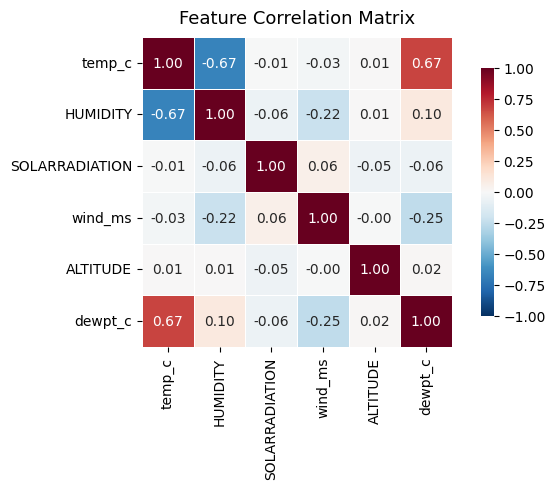

In [11]:
# ── Visual 5: Correlation heatmap ─────────────────────────────────────────────
corr_cols = ['temp_c','HUMIDITY','SOLARRADIATION','wind_ms','ALTITUDE','dewpt_c']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
            vmin=-1, vmax=1, ax=ax, square=True,
            linewidths=0.5, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=13, pad=10)
plt.tight_layout()
plt.show()

In [12]:
# ── Visual 6: Solar radiation vs temperature, coloured by humidity ────────────
sample = df.sample(min(8_000, len(df)), random_state=RANDOM_STATE)

fig_scatter = px.scatter(
    sample, x='SOLARRADIATION', y='temp_c',
    color='HUMIDITY', opacity=0.6,
    color_continuous_scale='RdYlBu_r',
    facet_col='year',
    labels={'SOLARRADIATION':'Solar Radiation (W/m2)',
            'temp_c':'Temperature (°C)',
            'HUMIDITY':'Humidity (%)'},
    title='Solar Radiation vs Temperature (coloured by Humidity)',
    template='plotly_white', height=400
)
fig_scatter.show()

In [13]:
# ── Visual 7: Diurnal temperature cycle per year ──────────────────────────────
df['hour'] = df['DATEUTC'].dt.hour
diurnal = df.groupby(['year','hour'])['temp_c'].mean().reset_index()

fig_diurnal = px.line(
    diurnal, x='hour', y='temp_c', color='year',
    color_discrete_sequence=px.colors.qualitative.Set2,
    markers=True,
    labels={'hour':'Hour (UTC)', 'temp_c':'Mean Temperature (°C)'},
    title='Average Diurnal Temperature Cycle — Q3 by Year',
    template='plotly_white', height=380
)
fig_diurnal.show()

In [14]:
# ── Visual 8: Altitude vs mean temperature per station ────────────────────────
stn_agg = (
    df.groupby(['ID','LATITUDE','LONGITUDE','ALTITUDE','year'])['temp_c']
      .mean().reset_index().rename(columns={'temp_c':'mean_temp_c'})
)

fig_alt = px.scatter(
    stn_agg, x='ALTITUDE', y='mean_temp_c',
    color='year', symbol='year',
    trendline='ols',
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={'ALTITUDE':'Station Altitude (m)', 'mean_temp_c':'Mean Temp (°C)'},
    title='Altitude vs Mean Temperature per Station',
    template='plotly_white', height=380
)
fig_alt.show()

---
## 4. Phase 3 — Feature Engineering

### 4a. Sentinel-2 Band Sampling & Spectral Indices

For each of the **7 Sentinel-2 scenes**, B04, B08 and B11 reflectance values are sampled  
at the GPS coordinates of every Leuven.cool station using `rasterio`.

| Index | Formula | Physical meaning |
|---|---|---|
| **NDVI** | (B08 − B04) / (B08 + B04) | Vegetation density — parks, gardens, trees |
| **NDBI** | (B11 − B08) / (B11 + B08) | Built-up intensity — rooftops, roads, concrete |

In [15]:
def sample_band_at_coords(band_path: Path, lats, lons) -> np.ndarray:
    """Read a single JP2 band and sample pixel values at (lat,lon) coordinates."""
    with rasterio.open(band_path) as src:
        from pyproj import Transformer
        transformer = Transformer.from_crs('EPSG:4326', src.crs.to_epsg(), always_xy=True)
        xs, ys = transformer.transform(lons, lats)
        rows, cols = rasterio.transform.rowcol(src.transform, xs, ys)
        rows = np.clip(rows, 0, src.height - 1)
        cols = np.clip(cols, 0, src.width  - 1)
        data   = src.read(1)
        values = data[rows, cols].astype(np.float32) / 10000.0  # DN -> reflectance
    return values


def load_sentinel_scene(scene_dir: Path, lats, lons):
    """Load B04, B08, B11 for one scene folder."""
    out = {}
    for band in ['B04', 'B08', 'B11']:
        jp2 = scene_dir / f'{band}.jp2'
        out[band] = sample_band_at_coords(jp2, lats, lons) if jp2.exists() \
                    else np.full(len(lats), np.nan)
    return out


def build_sentinel_features(stations_df: pd.DataFrame) -> pd.DataFrame:
    """
    Walk the 7 registered scene folders, sample bands at station coords,
    compute NDVI and NDBI. Returns one row per station x scene.
    """
    records = []
    lats = stations_df['LATITUDE'].values
    lons = stations_df['LONGITUDE'].values
    ids  = stations_df['ID'].values
    eps  = 1e-6

    # Only process the 7 known scenes — skip any other folders
    known_dates = set(d.strftime('%Y-%m-%d') for d in SCENE_DATES)
    scene_dirs  = sorted(
        d for d in SENTINEL_DIR.glob('????-??-??')
        if d.name in known_dates
    )

    for scene_dir in scene_dirs:
        scene_date = pd.Timestamp(scene_dir.name)
        print(f'  Processing {scene_dir.name}')
        bands = load_sentinel_scene(scene_dir, lats, lons)
        ndvi  = (bands['B08'] - bands['B04']) / (bands['B08'] + bands['B04'] + eps)
        ndbi  = (bands['B11'] - bands['B08']) / (bands['B11'] + bands['B08'] + eps)

        for i, sid in enumerate(ids):
            records.append({
                'ID':         sid,
                'scene_date': scene_date,
                'B04':        bands['B04'][i],
                'B08':        bands['B08'][i],
                'B11':        bands['B11'][i],
                'NDVI':       ndvi[i],
                'NDBI':       ndbi[i],
            })

    return pd.DataFrame(records)


sentinel_df = build_sentinel_features(stations)
print(f'Sentinel features: {len(sentinel_df):,} rows x {sentinel_df.shape[1]} cols')
sentinel_df.head(3)

  Processing 2023-08-10
  Processing 2023-08-20
  Processing 2023-08-23
  Processing 2024-07-30
  Processing 2025-07-02
  Processing 2025-08-11
  Processing 2025-08-12
Sentinel features: 1,085 rows x 7 cols


,ID,scene_date,B04,B08,B11,NDVI,NDBI
0,GARMON01,2023-08-10,0.1912,0.2441,0.3074,0.121525,0.114778
1,GARMON002,2023-08-10,0.1361,0.4870,0.3025,0.563151,-0.233692
2,GARMON003,2023-08-10,0.1362,0.4021,0.2826,0.493962,-0.174529


In [16]:
# ── Visual 9: NDVI and NDBI distributions across all scenes ──────────────────
fig_idx = make_subplots(rows=1, cols=2,
                        subplot_titles=['NDVI Distribution', 'NDBI Distribution'])

fig_idx.add_trace(go.Histogram(x=sentinel_df['NDVI'].dropna(),
                               marker_color='#55A868', name='NDVI', nbinsx=40),
                  row=1, col=1)
fig_idx.add_trace(go.Histogram(x=sentinel_df['NDBI'].dropna(),
                               marker_color='#C44E52', name='NDBI', nbinsx=40),
                  row=1, col=2)

fig_idx.update_layout(
    title='Spectral Index Distributions — all stations x 7 scenes',
    template='plotly_white', height=360, showlegend=False
)
fig_idx.show()

In [17]:
# ── Visual 10: NDVI by scene date — spatial variability across scenes ─────────
sentinel_df['scene_label'] = sentinel_df['scene_date'].dt.strftime('%Y-%m-%d')

fig_ndvi_scene = px.box(
    sentinel_df, x='scene_label', y='NDVI',
    color='scene_label',
    title='NDVI Distribution per Sentinel-2 Scene',
    labels={'scene_label': 'Scene Date', 'NDVI': 'NDVI'},
    template='plotly_white', height=380
)
fig_ndvi_scene.update_layout(showlegend=False)
fig_ndvi_scene.show()

### 4b. Temporal Alignment

Sensor readings are aggregated to **daily means per station**, then each day is matched  
to its nearest Sentinel-2 scene using a minimum absolute time-difference lookup.  
This is the merged feature table used for all ML models.

In [18]:
# Daily aggregation
df['date'] = df['DATEUTC'].dt.tz_localize(None).dt.normalize()

sensor_daily = (
    df.groupby(['ID', 'date', 'year'])
      .agg(
          temp_c         = ('temp_c',         'mean'),
          HUMIDITY       = ('HUMIDITY',        'mean'),
          SOLARRADIATION = ('SOLARRADIATION',  'mean'),
          wind_ms        = ('wind_ms',         'mean'),
          ALTITUDE       = ('ALTITUDE',        'first'),
          LATITUDE       = ('LATITUDE',        'first'),
          LONGITUDE      = ('LONGITUDE',       'first'),
      ).reset_index()
)

# Match each daily row to the nearest of the 7 scene dates
def nearest_scene(d):
    idx = np.argmin(np.abs((SCENE_DATES - d).total_seconds()))
    return SCENE_DATES[idx]

sensor_daily['scene_date'] = sensor_daily['date'].apply(nearest_scene)

# Merge Sentinel features
merged = sensor_daily.merge(sentinel_df, on=['ID', 'scene_date'], how='inner')
print(f'Merged feature table: {len(merged):,} rows  ({merged["year"].value_counts().to_dict()})')
merged.head(3)

Merged feature table: 266 rows  ({2023: 101, 2024: 98, 2025: 67})


,ID,date,year,temp_c,HUMIDITY,SOLARRADIATION,wind_ms,ALTITUDE,LATITUDE,LONGITUDE,scene_date,B04,B08,B11,NDVI,NDBI,scene_label
0,GARMON002,2023-07-01,2023,17.697835,70.766595,0.0,1.015403,47,50.8468,4.756,2023-08-10,0.1361,0.4870,0.3025,0.563151,-0.233692,2023-08-10
1,GARMON002,2024-07-01,2024,13.623179,99.000000,0.0,0.167163,47,50.8468,4.756,2024-07-30,0.1460,0.4731,0.3179,0.528347,-0.196207,2024-07-30
2,GARMON002,2025-07-01,2025,18.095748,92.229050,0.0,0.000000,47,50.8468,4.756,2025-07-02,0.1628,0.4433,0.3517,0.462794,-0.115220,2025-07-02


In [19]:
# ── Visual 11: NDVI vs Temperature scatter ────────────────────────────────────
fig_nv = px.scatter(
    merged, x='NDVI', y='temp_c', color='year',
    trendline='ols',
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={'NDVI':'NDVI (vegetation density)', 'temp_c':'Temperature (°C)'},
    title='NDVI vs Temperature — does more green mean cooler?',
    template='plotly_white', height=400
)
fig_nv.show()

In [20]:
# ── Visual 12: NDBI vs Temperature scatter ────────────────────────────────────
fig_nb = px.scatter(
    merged, x='NDBI', y='temp_c', color='year',
    trendline='ols',
    color_discrete_sequence=px.colors.qualitative.Set2,
    labels={'NDBI':'NDBI (built-up intensity)', 'temp_c':'Temperature (°C)'},
    title='NDBI vs Temperature — does more urban surface mean hotter?',
    template='plotly_white', height=400
)
fig_nb.show()

---
## 5. Phase 4 — ML Modeling

**Final merged feature table**

| Feature | Source | Description |
|---|---|---|
| NDVI | Sentinel-2 | Vegetation density |
| NDBI | Sentinel-2 | Built-up intensity |
| HUMIDITY | Leuven.cool | Daily mean relative humidity |
| ALTITUDE | STATIONS.csv | Station elevation (m) |
| wind_ms | Leuven.cool | Daily mean wind speed (m/s) |
| SOLARRADIATION | Leuven.cool | Daily mean solar radiation (W/m²) |

**Target:** `temp_c` — daily mean air temperature (°C)

In [21]:
FEATURES = ['NDVI', 'NDBI', 'HUMIDITY', 'ALTITUDE', 'wind_ms', 'SOLARRADIATION']
TARGET   = 'temp_c'

ml_df = merged[FEATURES + [TARGET, 'year']].dropna()

scaler      = StandardScaler()
X           = scaler.fit_transform(ml_df[FEATURES])
y           = ml_df[TARGET].values
year_labels = ml_df['year'].values

print(f'ML dataset: {len(ml_df):,} rows  |  features: {FEATURES}')

ML dataset: 266 rows  |  features: ['NDVI', 'NDBI', 'HUMIDITY', 'ALTITUDE', 'wind_ms', 'SOLARRADIATION']


### 5a. Train / Test Split — 80/20 + 5-Fold Cross-Validation

- **80/20 split** stratified by `year` — ensures 2023, 2024 and 2025 all appear in both train and test sets  
- **5-fold cross-validation** on the training set — used for model selection and hyperparameter tuning

In [22]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
for train_idx, test_idx in sss.split(X, year_labels):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]
    years_test      = year_labels[test_idx]

kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')
print(f'5-Fold CV ready — ~{len(X_train)//N_FOLDS:,} rows per fold')

Train : 212 | Test : 54
5-Fold CV ready — ~42 rows per fold


### 5b. Random Forest

In [23]:
rf = RandomForestRegressor(
    n_estimators=100, max_depth=12, n_jobs=-1, random_state=RANDOM_STATE
)
rf_cv = np.sqrt(-cross_val_score(
    rf, X_train, y_train, cv=kf,
    scoring='neg_mean_squared_error', n_jobs=-1
))
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)
print(f'RF  RMSE: {rf_rmse:.3f} | MAE: {rf_mae:.3f} | R2: {rf_r2:.3f}')
print(f'RF  5-CV: {rf_cv.mean():.3f} +/- {rf_cv.std():.3f}')

RF  RMSE: 1.112 | MAE: 0.609 | R2: 0.856
RF  5-CV: 1.265 +/- 0.342


### 5c. XGBoost

In [24]:
xgb_model = xgb.XGBRegressor(
    n_estimators=200, max_depth=6, learning_rate=0.05,
    subsample=0.8, tree_method='hist',
    random_state=RANDOM_STATE, verbosity=0
)
xgb_cv = np.sqrt(-cross_val_score(
    xgb_model, X_train, y_train, cv=kf,
    scoring='neg_mean_squared_error', n_jobs=-1
))
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mae  = mean_absolute_error(y_test, xgb_pred)
xgb_r2   = r2_score(y_test, xgb_pred)
print(f'XGB RMSE: {xgb_rmse:.3f} | MAE: {xgb_mae:.3f} | R2: {xgb_r2:.3f}')
print(f'XGB 5-CV: {xgb_cv.mean():.3f} +/- {xgb_cv.std():.3f}')

XGB RMSE: 1.188 | MAE: 0.603 | R2: 0.836
XGB 5-CV: 1.282 +/- 0.370


### 5d. CNN (Convolutional Neural Network)

Sentinel-2 bands (B04, B08, B11) are extracted as **16×16 pixel image patches** centred on each station GPS coordinate.  
The CNN learns spatial context — green corridors, rooftop density, shadow patterns — that tabular features cannot capture.

**Architecture:**  
`Conv2d(3→16) → ReLU → MaxPool → Conv2d(16→32) → ReLU → MaxPool → Flatten → Linear(64) → ReLU → Linear(1)`  
**Image patches · ReLU · Adam optimizer**

In [25]:
class HeatCNN(nn.Module):
    """CNN for urban heat regression from Sentinel-2 image patches."""
    def __init__(self, in_channels=3, patch_size=PATCH_SIZE):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, 3, padding=1),          nn.ReLU(), nn.MaxPool2d(2),
        )
        flat = 32 * (patch_size // 4) ** 2
        self.head = nn.Sequential(
            nn.Flatten(), nn.Linear(flat, 64), nn.ReLU(), nn.Linear(64, 1)
        )
    def forward(self, x):
        return self.head(self.conv(x)).squeeze(1)


def extract_patch(band_path: Path, lat, lon, size=PATCH_SIZE):
    """Extract a (size x size) patch centred on (lat,lon)."""
    with rasterio.open(band_path) as src:
        from pyproj import Transformer
        tr = Transformer.from_crs('EPSG:4326', src.crs.to_epsg(), always_xy=True)
        x, y = tr.transform(lon, lat)
        r, c = rasterio.transform.rowcol(src.transform, x, y)
        half   = size // 2
        window = rasterio.windows.Window(max(0, c-half), max(0, r-half), size, size)
        patch  = src.read(1, window=window).astype(np.float32) / 10000.0
        if patch.shape != (size, size):
            pad = np.zeros((size, size), dtype=np.float32)
            pad[:patch.shape[0], :patch.shape[1]] = patch
            patch = pad
    return patch


def build_patch_dataset(merged_df, patch_size=PATCH_SIZE):
    """Extract multi-band patches for every row. Returns (N,3,P,P) + targets."""
    patches, targets = [], []
    for _, row in merged_df.iterrows():
        scene_dir = SENTINEL_DIR / str(row['scene_date'].date())
        bands, ok = [], True
        for band in ['B04','B08','B11']:
            jp2 = scene_dir / f'{band}.jp2'
            if not jp2.exists(): ok = False; break
            bands.append(extract_patch(jp2, row['LATITUDE'], row['LONGITUDE'], patch_size))
        if ok:
            patches.append(np.stack(bands))
            targets.append(row[TARGET])
    return np.array(patches, dtype=np.float32), np.array(targets, dtype=np.float32)


X_patches, y_patches = build_patch_dataset(merged)
print(f'Patch dataset: {X_patches.shape}')

Patch dataset: (266, 3, 16, 16)


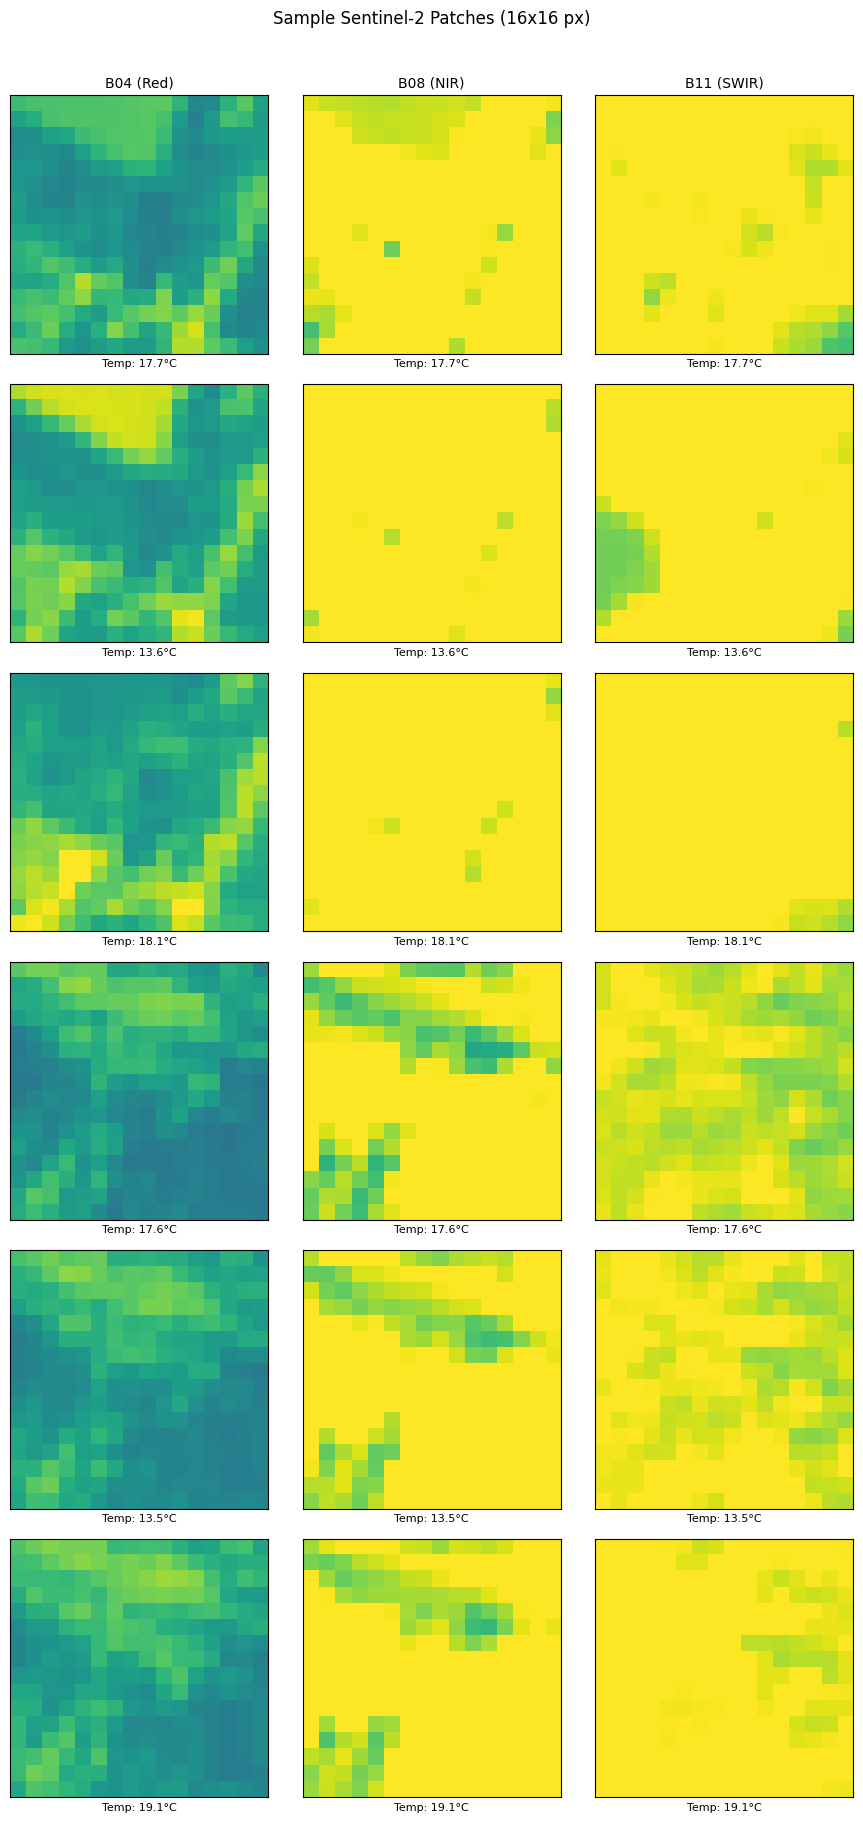

In [26]:
# ── Visual 13: Sample image patches (B04 / B08 / B11) ────────────────────────
n_show     = min(6, len(X_patches))
band_names = ['B04 (Red)', 'B08 (NIR)', 'B11 (SWIR)']
fig, axes  = plt.subplots(n_show, 3, figsize=(9, n_show * 3))

for i in range(n_show):
    for j in range(3):
        ax = axes[i, j]
        ax.imshow(X_patches[i, j], cmap='viridis', vmin=0, vmax=0.3)
        if i == 0: ax.set_title(band_names[j], fontsize=10)
        ax.set_xlabel(f'Temp: {y_patches[i]:.1f}°C', fontsize=8)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle(f'Sample Sentinel-2 Patches ({PATCH_SIZE}x{PATCH_SIZE} px)',
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [27]:
from sklearn.model_selection import train_test_split as tts
Xp_tr, Xp_te, yp_tr, yp_te = tts(
    X_patches, y_patches, test_size=0.2, random_state=RANDOM_STATE
)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(Xp_tr), torch.from_numpy(yp_tr)),
    batch_size=32, shuffle=True
)

cnn_model   = HeatCNN().to(DEVICE)
optimizer   = optim.Adam(cnn_model.parameters(), lr=1e-3)
criterion   = nn.MSELoss()
EPOCHS      = 10   # raise to 30-50 for final run
loss_history = []

cnn_model.train()
for epoch in range(1, EPOCHS + 1):
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(cnn_model(xb), yb)
        loss.backward(); optimizer.step()
        epoch_loss += loss.item()
    avg = epoch_loss / len(train_loader)
    loss_history.append(avg)
    if epoch % 2 == 0 or epoch == 1:
        print(f'Epoch {epoch:02d}/{EPOCHS}  loss: {avg:.4f}')

cnn_model.eval()
with torch.no_grad():
    cnn_pred = cnn_model(torch.from_numpy(Xp_te).to(DEVICE)).cpu().numpy()

cnn_rmse = np.sqrt(mean_squared_error(yp_te, cnn_pred))
cnn_mae  = mean_absolute_error(yp_te, cnn_pred)
cnn_r2   = r2_score(yp_te, cnn_pred)
print(f'CNN  RMSE: {cnn_rmse:.3f} | MAE: {cnn_mae:.3f} | R2: {cnn_r2:.3f}')

Epoch 01/10  loss: 302.1461
Epoch 02/10  loss: 277.9571
Epoch 04/10  loss: 90.5730
Epoch 06/10  loss: 27.4398
Epoch 08/10  loss: 14.9670
Epoch 10/10  loss: 11.5084
CNN  RMSE: 3.015 | MAE: 2.658 | R2: -0.227


In [28]:
# ── Visual 14: CNN training loss curve ───────────────────────────────────────
fig_loss = px.line(
    x=list(range(1, EPOCHS+1)), y=loss_history,
    markers=True,
    labels={'x':'Epoch', 'y':'MSE Loss'},
    title='CNN Training Loss Curve',
    template='plotly_white', height=350
)
fig_loss.update_traces(line_color='#C44E52')
fig_loss.show()

### 5e. Hyperparameter Tuning — XGBoost (RandomizedSearchCV, 5-fold)

In [29]:
search = RandomizedSearchCV(
    xgb.XGBRegressor(tree_method='hist', verbosity=0, random_state=RANDOM_STATE),
    param_distributions={
        'n_estimators':  [100, 200, 300],
        'max_depth':     [4, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1],
        'subsample':     [0.7, 0.8, 1.0],
    },
    n_iter=10, scoring='neg_root_mean_squared_error',
    cv=kf, n_jobs=-1, random_state=RANDOM_STATE, verbose=1
)
search.fit(X_train, y_train)
best_xgb  = search.best_estimator_
best_pred = best_xgb.predict(X_test)
best_rmse = np.sqrt(mean_squared_error(y_test, best_pred))
best_mae  = mean_absolute_error(y_test, best_pred)
best_r2   = r2_score(y_test, best_pred)
print(f'Best params: {search.best_params_}')
print(f'Tuned XGB   RMSE: {best_rmse:.3f} | MAE: {best_mae:.3f} | R2: {best_r2:.3f}')

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'subsample': 0.8, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.05}
Tuned XGB   RMSE: 1.137 | MAE: 0.597 | R2: 0.849


---
## 6. Phase 5 — Evaluation & Model Comparison

### 6a. Metrics Summary

In [30]:
results = pd.DataFrame([
    {'Model': 'Random Forest',   'RMSE': rf_rmse,   'MAE': rf_mae,   'R2': rf_r2,   'CV RMSE': rf_cv.mean()},
    {'Model': 'XGBoost',         'RMSE': xgb_rmse,  'MAE': xgb_mae,  'R2': xgb_r2,  'CV RMSE': xgb_cv.mean()},
    {'Model': 'XGBoost (tuned)', 'RMSE': best_rmse, 'MAE': best_mae, 'R2': best_r2, 'CV RMSE': abs(search.best_score_)},
    {'Model': 'CNN',             'RMSE': cnn_rmse,  'MAE': cnn_mae,  'R2': cnn_r2,  'CV RMSE': float('nan')},
]).set_index('Model').round(4)

print(results.to_string())

                   RMSE     MAE      R2  CV RMSE
Model                                           
Random Forest    1.1116  0.6087  0.8562   1.2655
XGBoost          1.1878  0.6030  0.8359   1.2822
XGBoost (tuned)  1.1374  0.5974  0.8495   1.2625
CNN              3.0145  2.6578 -0.2275      NaN


In [31]:
# ── Visual 15: RMSE & MAE comparison bar charts ───────────────────────────────
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
models = results.index.tolist()

fig_cmp = make_subplots(rows=1, cols=2,
                        subplot_titles=['RMSE Comparison', 'MAE Comparison'])
fig_cmp.add_trace(go.Bar(x=models, y=results['RMSE'].values,
                         marker_color=colors, showlegend=False,
                         text=results['RMSE'].round(3).values,
                         textposition='outside'), row=1, col=1)
fig_cmp.add_trace(go.Bar(x=models, y=results['MAE'].values,
                         marker_color=colors, showlegend=False,
                         text=results['MAE'].round(3).values,
                         textposition='outside'), row=1, col=2)
fig_cmp.update_layout(title='Model Comparison — Test Set Performance',
                      height=420, template='plotly_white')
fig_cmp.show()

In [32]:
# ── Visual 16: Radar chart of normalised metrics ──────────────────────────────
radar_df = results[['RMSE','MAE','R2']].copy()
radar_df['RMSE_score'] = 1 - (radar_df['RMSE'] - radar_df['RMSE'].min()) / (radar_df['RMSE'].max() - radar_df['RMSE'].min() + 1e-6)
radar_df['MAE_score']  = 1 - (radar_df['MAE']  - radar_df['MAE'].min())  / (radar_df['MAE'].max()  - radar_df['MAE'].min()  + 1e-6)
radar_df['R2_score']   = (radar_df['R2'] - radar_df['R2'].min()) / (radar_df['R2'].max() - radar_df['R2'].min() + 1e-6)

cats = ['RMSE score','MAE score','R2 score']
fig_radar = go.Figure()
for i, (model, row) in enumerate(radar_df.iterrows()):
    vals = [row['RMSE_score'], row['MAE_score'], row['R2_score']]
    fig_radar.add_trace(go.Scatterpolar(
        r=vals + [vals[0]], theta=cats + [cats[0]],
        fill='toself', name=model,
        line_color=colors[i], opacity=0.6
    ))
fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0,1])),
    title='Model Performance Radar (normalised — higher = better)',
    template='plotly_white', height=420
)
fig_radar.show()

In [33]:
# ── Visual 17: RMSE per year ──────────────────────────────────────────────────
year_records = []
for yr in YEARS:
    mask = years_test == yr
    if mask.sum() == 0: continue
    for m_name, preds in [('Random Forest', rf_pred), ('XGBoost (tuned)', best_pred)]:
        year_records.append({
            'Year': yr, 'Model': m_name,
            'RMSE': np.sqrt(mean_squared_error(y_test[mask], preds[mask])),
            'MAE':  mean_absolute_error(y_test[mask], preds[mask]),
        })
year_df = pd.DataFrame(year_records)

fig_yr = px.bar(
    year_df, x='Year', y='RMSE', color='Model', barmode='group',
    title='RMSE per Year — Model Comparison',
    color_discrete_sequence=['#4C72B0','#55A868'],
    template='plotly_white', height=380
)
fig_yr.show()
print(year_df.round(4).to_string(index=False))

 Year           Model   RMSE    MAE
 2023   Random Forest 0.5601 0.3667
 2023 XGBoost (tuned) 0.2814 0.2139
 2024   Random Forest 0.9841 0.5863
 2024 XGBoost (tuned) 1.1097 0.6467
 2025   Random Forest 1.7131 0.9864
 2025 XGBoost (tuned) 1.7656 1.0747


In [34]:
# ── Visual 18: Predicted vs Actual scatter ────────────────────────────────────
pva = pd.DataFrame({'Actual': y_test, 'RF': rf_pred, 'XGB': best_pred})

fig_pva = make_subplots(rows=1, cols=2,
                        subplot_titles=['Random Forest', 'XGBoost (tuned)'])
for col_i, (m, col) in enumerate([('RF','#4C72B0'),('XGB','#55A868')], start=1):
    fig_pva.add_trace(go.Scatter(
        x=pva['Actual'], y=pva[m], mode='markers',
        marker=dict(color=col, opacity=0.5, size=6), showlegend=False
    ), row=1, col=col_i)
    lim = [pva['Actual'].min(), pva['Actual'].max()]
    fig_pva.add_trace(go.Scatter(
        x=lim, y=lim, mode='lines',
        line=dict(color='red', dash='dash'), showlegend=False
    ), row=1, col=col_i)

fig_pva.update_xaxes(title_text='Actual (°C)')
fig_pva.update_yaxes(title_text='Predicted (°C)')
fig_pva.update_layout(title='Predicted vs Actual Temperature',
                      height=420, template='plotly_white')
fig_pva.show()

In [35]:
# ── Visual 19: Feature importance ────────────────────────────────────────────
imp_rf  = pd.Series(rf.feature_importances_,       index=FEATURES)
imp_xgb = pd.Series(best_xgb.feature_importances_, index=FEATURES)

fig_imp = make_subplots(rows=1, cols=2,
                        subplot_titles=['Random Forest', 'XGBoost (tuned)'])
for col_i, (imp, col) in enumerate(
        [(imp_rf.sort_values(),'#4C72B0'), (imp_xgb.sort_values(),'#55A868')],
        start=1):
    fig_imp.add_trace(go.Bar(
        x=imp.values, y=imp.index,
        orientation='h', marker_color=col, showlegend=False
    ), row=1, col=col_i)
fig_imp.update_layout(title='Feature Importance',
                      height=380, template='plotly_white')
fig_imp.show()

In [36]:
tabular_results = results.drop('CNN')
best_name = tabular_results['RMSE'].idxmin()
best_model_obj = {'Random Forest': rf,
                  'XGBoost': xgb_model,
                  'XGBoost (tuned)': best_xgb}[best_name]

print(f'Best model  : {best_name}')
print(f'Test RMSE   : {results.loc[best_name, "RMSE"]:.4f} C')
print('Selected as spatial predictor for heat risk mapping.')

Best model  : Random Forest
Test RMSE   : 1.1116 C
Selected as spatial predictor for heat risk mapping.


---
## 7. Phase 6 — Visualization & Heat Risk Map

### 7a. Spatial Prediction Grid

A dense lat/lon grid (60×60 = 3 600 points) is constructed over Leuven.  
B04, B08, B11 are sampled from the latest available Sentinel-2 scene at each grid point.  
Weather features are set to the Q3 median values from the sensor network.

In [37]:
GRID_STEPS = 60   # raise to 150 for publication

lat_grid = np.linspace(LAT_MIN, LAT_MAX, GRID_STEPS)
lon_grid = np.linspace(LON_MIN, LON_MAX, GRID_STEPS)
LAT_G, LON_G = np.meshgrid(lat_grid, lon_grid)
n_grid   = LAT_G.size
grid_lats = LAT_G.ravel()
grid_lons = LON_G.ravel()

# Latest Sentinel-2 scene
latest_scene = SENTINEL_DIR / SCENE_DATES[-1].strftime('%Y-%m-%d')
bands_grid   = {}
eps = 1e-6
for band in ['B04','B08','B11']:
    jp2 = latest_scene / f'{band}.jp2'
    bands_grid[band] = sample_band_at_coords(jp2, grid_lats, grid_lons) \
                       if jp2.exists() else np.full(n_grid, np.nan)

ndvi_grid = (bands_grid['B08'] - bands_grid['B04']) / (bands_grid['B08'] + bands_grid['B04'] + eps)
ndbi_grid = (bands_grid['B11'] - bands_grid['B08']) / (bands_grid['B11'] + bands_grid['B08'] + eps)

grid_X = np.column_stack([
    ndvi_grid,
    ndbi_grid,
    np.full(n_grid, df['HUMIDITY'].median()),
    np.full(n_grid, df['ALTITUDE'].median()),
    np.full(n_grid, df['wind_ms'].median()),
    np.full(n_grid, df['SOLARRADIATION'].median()),
])
nan_mask = np.any(np.isnan(grid_X), axis=1)
for c in range(grid_X.shape[1]):
    grid_X[nan_mask, c] = np.nanmedian(grid_X[:, c])

grid_temp = best_model_obj.predict(scaler.transform(grid_X)).reshape(LAT_G.shape)

print(f'Grid: {GRID_STEPS}x{GRID_STEPS} = {n_grid:,} points')
print(f'Predicted range: {grid_temp.min():.2f} - {grid_temp.max():.2f} C')

Grid: 60x60 = 3,600 points
Predicted range: 19.70 - 20.73 C


In [38]:
# ── Visual 20: Interactive Urban Heat Dashboard ───────────────────────────────
fig_map = go.Figure(go.Heatmap(
    z=grid_temp, x=lon_grid, y=lat_grid,
    colorscale='RdYlBu_r',
    colorbar=dict(title='°C'),
    hovertemplate='Lon: %{x:.4f}<br>Lat: %{y:.4f}<br>Temp: %{z:.2f}°C<extra></extra>'
))
fig_map.add_trace(go.Scatter(
    x=stations['LONGITUDE'], y=stations['LATITUDE'],
    mode='markers',
    marker=dict(color='black', size=5, symbol='circle'),
    name='Stations',
    hovertemplate='%{text}<extra></extra>',
    text=stations['ID']
))
fig_map.update_layout(
    title=f'Urban Heat Risk · Leuven — {best_name} Predictions (latest scene: {SCENE_DATES[-1].date()})',
    xaxis_title='Longitude', yaxis_title='Latitude',
    height=580, template='plotly_white'
)
fig_map.show()

In [39]:
# ── Visual 21: Multi-year heat comparison — one mid-summer scene per year ─────
#
#  2023: 3 scenes  → use 2023-08-20 (middle)
#  2024: 1 scene   → use 2024-07-30
#  2025: 3 scenes  → use 2025-08-11 (middle)
#
REPRESENTATIVE_SCENES = {
    2023: '2023-08-20',
    2024: '2024-07-30',
    2025: '2025-08-11',
}

fig_multi = make_subplots(
    rows=1, cols=3,
    subplot_titles=[f'{yr}  ({REPRESENTATIVE_SCENES[yr]})' for yr in YEARS],
    horizontal_spacing=0.05
)

for col_i, yr in enumerate(YEARS, start=1):
    scene_dir = SENTINEL_DIR / REPRESENTATIVE_SCENES[yr]
    b_yr = {}
    for band in ['B04','B08','B11']:
        jp2 = scene_dir / f'{band}.jp2'
        b_yr[band] = sample_band_at_coords(jp2, grid_lats, grid_lons) \
                     if jp2.exists() else np.full(n_grid, np.nan)

    ndvi_yr = (b_yr['B08'] - b_yr['B04']) / (b_yr['B08'] + b_yr['B04'] + eps)
    ndbi_yr = (b_yr['B11'] - b_yr['B08']) / (b_yr['B11'] + b_yr['B08'] + eps)

    yr_df = df[df['year'] == yr]
    gX_yr = np.column_stack([
        ndvi_yr, ndbi_yr,
        np.full(n_grid, yr_df['HUMIDITY'].median()),
        np.full(n_grid, yr_df['ALTITUDE'].median()),
        np.full(n_grid, yr_df['wind_ms'].median()),
        np.full(n_grid, yr_df['SOLARRADIATION'].median()),
    ])
    nan_yr = np.any(np.isnan(gX_yr), axis=1)
    for c in range(gX_yr.shape[1]):
        gX_yr[nan_yr, c] = np.nanmedian(gX_yr[:, c])

    gt_yr = best_model_obj.predict(scaler.transform(gX_yr)).reshape(LAT_G.shape)

    fig_multi.add_trace(go.Heatmap(
        z=gt_yr, x=lon_grid, y=lat_grid,
        colorscale='RdYlBu_r',
        zmin=grid_temp.min(), zmax=grid_temp.max(),
        showscale=(col_i == 3),
        colorbar=dict(title='°C', x=1.01)
    ), row=1, col=col_i)

fig_multi.update_layout(
    title='Multi-Year Urban Heat Comparison — Representative Scene per Year',
    height=430, template='plotly_white'
)
fig_multi.show()

In [40]:
# ── Visual 22: Heat risk category map ────────────────────────────────────────
risk_flat = grid_temp.ravel()
risk_cat  = pd.cut(
    risk_flat,
    bins=[-np.inf, 16, 18, 20, 22, np.inf],
    labels=['Cool','Mild','Warm','Hot','Very Hot']
)

risk_df = pd.DataFrame({
    'lat':  grid_lats, 'lon': grid_lons,
    'temp': risk_flat, 'risk': risk_cat
})

fig_risk = px.scatter_mapbox(
    risk_df, lat='lat', lon='lon',
    color='risk',
    color_discrete_map={
        'Cool':     '#313695',
        'Mild':     '#74ADD1',
        'Warm':     '#FEE090',
        'Hot':      '#F46D43',
        'Very Hot': '#A50026'
    },
    hover_data={'temp': ':.2f'},
    zoom=12, mapbox_style='carto-positron',
    title='Urban Heat Risk Categories · Leuven',
    height=560
)
fig_risk.show()

---
## 8. Phase 7 — Deployment

| Output | Format | Use |
|---|---|---|
| This notebook | `.ipynb` | Reproducible end-to-end pipeline |
| Interactive heat map | `.html` | Presentation / stakeholder sharing |
| Heat risk categories map | `.html` | Policy / urban planning overlay |

In [41]:
fig_map.write_html('leuven_heat_dashboard.html')
fig_risk.write_html('leuven_heat_risk_categories.html')
print('Exported:')
print('  leuven_heat_dashboard.html')
print('  leuven_heat_risk_categories.html')

Exported:
  leuven_heat_dashboard.html
  leuven_heat_risk_categories.html


---
*Urban Heat Intelligence · Leuven 2023–2025 — AI-assisted urban heat risk prediction using satellite imagery and environmental sensing.*

**Data sources:**  
Leuven.cool citizen science weather network — Zenodo [DOI 10.5281/zenodo.14893734](https://zenodo.org/records/14893734)  
Sentinel-2 L2A imagery (B04, B08, B11) — ESA Copernicus · 7 low-cloud summer scenes 2023–2025